<a href="https://colab.research.google.com/github/ChantelRM/Pursuit-Financial-Risk-Engine/blob/main/financial_risk_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Financial Risk Analytics Engine
### Debtor risk scoring, collections notifications, and a "worth pursuing" prediction model

Run cells top to bottom. Sections are self-contained — you can re-run a
section without re-running the whole notebook while iterating.

**Runtime:** Runtime > Change runtime type > select **R**


## 0. Setup

In [77]:
required_packages <- c("dplyr", "ggplot2", "tibble", "purrr", "glue",
                        "scales", "lubridate", "readr", "tidyr", "stringr", "httr", "jsonlite")

new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(new_packages) > 0) install.packages(new_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))

set.seed(42)
dir.create("outputs", showWarnings = FALSE)
dir.create("outputs/charts", showWarnings = FALSE)
dir.create("models", showWarnings = FALSE)
dir.create("data/raw", recursive = TRUE, showWarnings = FALSE)
dir.create("data/processed", recursive = TRUE, showWarnings = FALSE)


In [78]:
# API SETUP
# api_key <- system('python3 -c "from google.colab import userdata; print(userdata.get(\'ANTHROPIC_API_KEY\'))"', intern = TRUE)
# Sys.setenv(ANTHROPIC_API_KEY = api_key)

## 1. Data Architecture & Schema Contracts

- **Master Ledger**: `Debtor_ID, Debtor_Name, Billing_Month, Original_Debt, Amount_Paid, Cost_To_Acquire`
- **External Risk Registry**: `Debtor_ID, Is_Blacklisted, Has_External_Debts`

`validate_schema()` fails loudly on a missing/mistyped column instead of
letting a bad join or bad chart happen silently three cells later.


In [79]:
MASTER_LEDGER_SCHEMA <- list(
  Debtor_ID = "integer", Debtor_Name = "character", Billing_Month = "Date",
  Original_Debt = "numeric", Amount_Paid = "numeric", Cost_To_Acquire = "numeric"
)

RISK_REGISTRY_SCHEMA <- list(
  Debtor_ID = "integer", Is_Blacklisted = "logical", Has_External_Debts = "logical"
)

validate_schema <- function(df, schema, df_name = "dataset") {
  missing_cols <- setdiff(names(schema), names(df))
  if (length(missing_cols) > 0) {
    stop(glue("[{df_name}] Missing required columns: {paste(missing_cols, collapse = ', ')}"))
  }
  problems <- c()
  for (col in names(schema)) {
    expected <- schema[[col]]
    actual_class <- class(df[[col]])[1]
    ok <- (actual_class == expected) ||
      (expected == "numeric" && actual_class %in% c("numeric", "integer")) ||
      (expected == "integer" && actual_class %in% c("numeric", "integer"))
    if (!ok) problems <- c(problems, glue("  - {col}: expected {expected}, got {actual_class}"))
  }
  if (length(problems) > 0) stop(glue("[{df_name}] Schema mismatches:\n{paste(problems, collapse = '\n')}"))
  message(glue("[{df_name}] Schema OK ({nrow(df)} rows, {ncol(df)} cols)"))
  invisible(TRUE)
}

load_and_validate_csv <- function(path, schema, df_name = "dataset", date_cols = character(0)) {
  df <- readr::read_csv(path, show_col_types = FALSE)
  for (dc in date_cols) if (dc %in% names(df)) df[[dc]] <- as.Date(df[[dc]])
  validate_schema(df, schema, df_name)
  df
}


## 2. Data: Simulated (for now) or Real

Starts with simulated data so the whole pipeline runs today. Switch
`USE_REAL_DATA <- TRUE` once your Kaggle CSVs are uploaded to `data/raw/`
and mapped correctly (see Section 5 for the ML datasets specifically).


In [80]:
USE_REAL_DATA <- FALSE  # flip once your real Master Ledger / Risk Registry CSVs are ready

simulate_master_ledger <- function(n = 250) {
  original_debt <- round(runif(n, 500, 12000), 2)
  payment_ratio <- rbeta(n, 2, 3)
  tibble(
    Debtor_ID = 1:n,
    Debtor_Name = paste0("Debtor_", str_pad(1:n, 4, pad = "0")),
    Billing_Month = sample(seq(as.Date("2025-01-01"), as.Date("2025-12-01"), by = "month"), n, replace = TRUE),
    Original_Debt = original_debt,
    Amount_Paid = round(pmin(original_debt, original_debt * payment_ratio), 2),
    Cost_To_Acquire = round(runif(n, 40, 450), 2)
  )
}

simulate_risk_registry <- function(n = 250) {
  tibble(
    Debtor_ID = 1:n,
    Is_Blacklisted = sample(c(TRUE, FALSE), n, replace = TRUE, prob = c(0.14, 0.86)),
    Has_External_Debts = sample(c(TRUE, FALSE), n, replace = TRUE, prob = c(0.22, 0.78))
  )
}

if (USE_REAL_DATA) {
  master_ledger <- load_and_validate_csv("data/raw/master_ledger.csv", MASTER_LEDGER_SCHEMA,
                                          "Master Ledger", date_cols = "Billing_Month")
  external_risk_registry <- load_and_validate_csv("data/raw/risk_registry.csv", RISK_REGISTRY_SCHEMA,
                                                    "External Risk Registry")
} else {
  master_ledger <- simulate_master_ledger(250)
  external_risk_registry <- simulate_risk_registry(250)
  validate_schema(master_ledger, MASTER_LEDGER_SCHEMA, "Master Ledger")
  validate_schema(external_risk_registry, RISK_REGISTRY_SCHEMA, "External Risk Registry")
}


[Master Ledger] Schema OK (250 rows, 6 cols)

[External Risk Registry] Schema OK (250 rows, 3 cols)



## 3. Merge & Risk Computations

In [81]:
unified_ledger <- master_ledger %>% left_join(external_risk_registry, by = "Debtor_ID")
stopifnot(nrow(unified_ledger) == nrow(master_ledger))

unified_ledger <- unified_ledger %>%
  mutate(
    Remaining_Balance = round(Original_Debt - Amount_Paid, 2),
    Net_Profit = round(Amount_Paid - Cost_To_Acquire, 2),
    Days_Past_Due = as.integer(Sys.Date() - Billing_Month),
    Critical_Alert = Remaining_Balance > 0 & (Is_Blacklisted | Has_External_Debts),
    Risk_Tier = case_when(
      Critical_Alert & Remaining_Balance > 5000 ~ "Severe",
      Critical_Alert ~ "Critical",
      Remaining_Balance > 0 ~ "Watch",
      TRUE ~ "Clear"
    )
  )

message(glue("Flagged {sum(unified_ledger$Critical_Alert)} of {nrow(unified_ledger)} accounts as Critical Alert."))
write_csv(unified_ledger, "data/processed/unified_ledger.csv")
head(unified_ledger)


Flagged 82 of 250 accounts as Critical Alert.



Debtor_ID,Debtor_Name,Billing_Month,Original_Debt,Amount_Paid,Cost_To_Acquire,Is_Blacklisted,Has_External_Debts,Remaining_Balance,Net_Profit,Days_Past_Due,Critical_Alert,Risk_Tier
<int>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<int>,<lgl>,<chr>
1,Debtor_0001,2025-04-01,11020.27,3284.61,357.10,FALSE,FALSE,7735.66,2927.51,473,FALSE,Watch
2,Debtor_0002,2025-12-01,11276.37,2906.82,398.09,FALSE,FALSE,8369.55,2508.73,229,FALSE,Watch
3,Debtor_0003,2025-07-01,3790.60,550.78,293.51,FALSE,FALSE,3239.82,257.27,382,FALSE,Watch
4,Debtor_0004,2025-01-01,10050.15,4480.36,186.67,FALSE,FALSE,5569.79,4293.69,563,FALSE,Watch
5,Debtor_0005,2025-08-01,7880.07,4325.34,422.23,FALSE,FALSE,3554.73,3903.11,351,FALSE,Watch
6,Debtor_0006,2025-05-01,6469.60,1835.59,345.34,FALSE,TRUE,4634.01,1490.25,443,TRUE,Critical


## 4. Notification Drafts (email + SMS)

In [82]:
generate_email_draft <- function(row) {
  glue(
"Subject: URGENT: Outstanding Balance Notice - Account #{row$Debtor_ID}

Dear {row$Debtor_Name},

This notice is to formally inform you that our records show an outstanding
balance on your account that requires immediate attention.

  Account Reference:     {row$Debtor_ID}
  Outstanding Balance:   ${format(row$Remaining_Balance, big.mark=',', nsmall=2)}
  Days Past Due:         {row$Days_Past_Due} days
  Risk Classification:   {row$Risk_Tier}

Please settle this balance or contact us to arrange a payment plan within
7 days of this notice to avoid further collection action.

Regards,
Accounts Recovery Team"
  )
}

generate_sms_draft <- function(row) {
  msg <- glue(
    "ALERT: Acct #{row$Debtor_ID}, balance ${format(row$Remaining_Balance, nsmall=2)} ",
    "is {row$Days_Past_Due}d overdue. Pay within 7 days to avoid legal/credit ",
    "action. Reply HELP for options."
  )
  if (nchar(msg) > 160) {
    msg <- glue(
      "ALERT: Acct #{row$Debtor_ID} owes ${format(row$Remaining_Balance, nsmall=0)}, ",
      "{row$Days_Past_Due}d overdue. Pay in 7 days to avoid escalation."
    )
  }
  as.character(msg)
}

critical_accounts <- unified_ledger %>% filter(Critical_Alert)

notification_queue <- critical_accounts %>%
  select(Debtor_ID, Debtor_Name, Remaining_Balance, Days_Past_Due, Risk_Tier) %>%
  mutate(
    Email_Draft = pmap_chr(critical_accounts, function(...) generate_email_draft(tibble(...))),
    SMS_Draft = pmap_chr(critical_accounts, function(...) generate_sms_draft(tibble(...))),
    SMS_Char_Count = nchar(SMS_Draft)
  )

write_csv(notification_queue, "outputs/notification_queue.csv")
if (nrow(notification_queue) > 0) cat(notification_queue$Email_Draft[1])


Subject: URGENT: Outstanding Balance Notice - Account #6

Dear Debtor_0006,

This notice is to formally inform you that our records show an outstanding
balance on your account that requires immediate attention.

  Account Reference:     6
  Outstanding Balance:   $4,634.01
  Days Past Due:         443 days
  Risk Classification:   Critical

Please settle this balance or contact us to arrange a payment plan within
7 days of this notice to avoid further collection action.

Regards,
Accounts Recovery Team

## 5. Visualizations

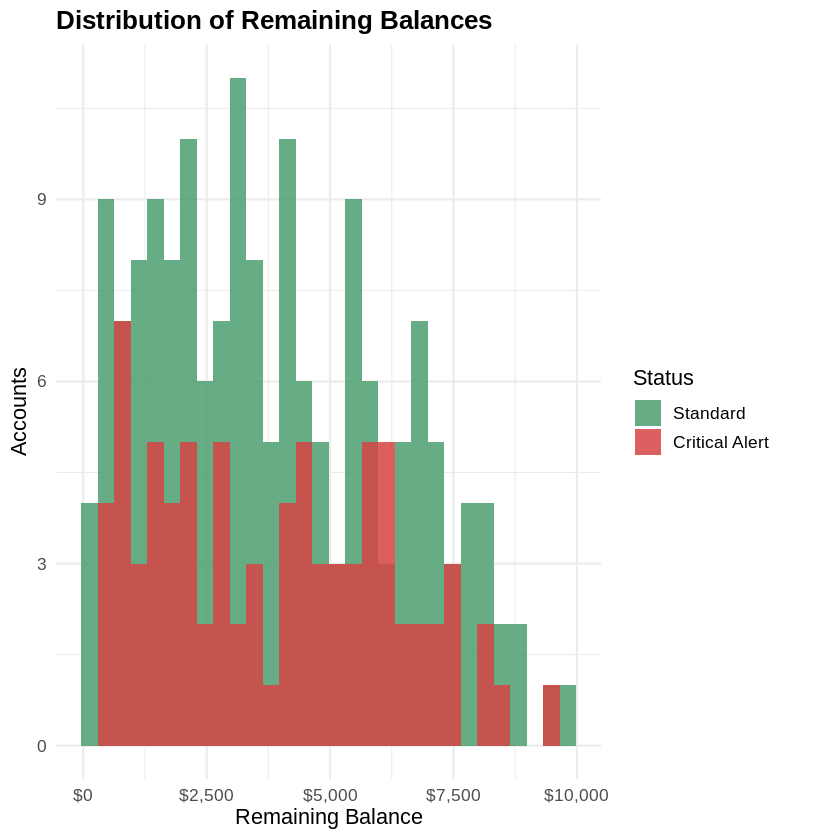

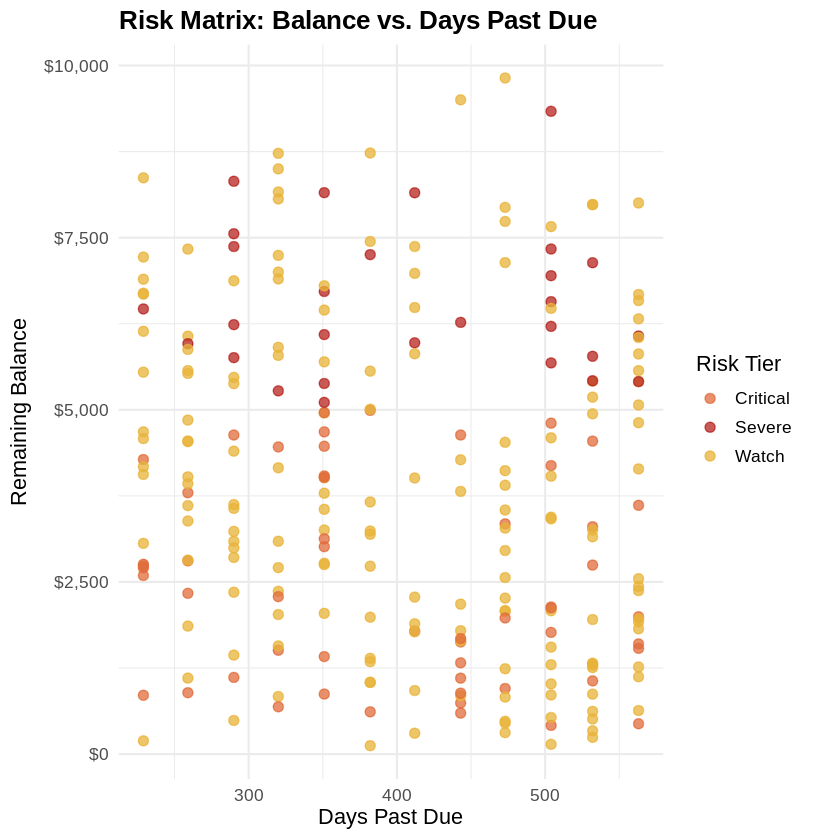

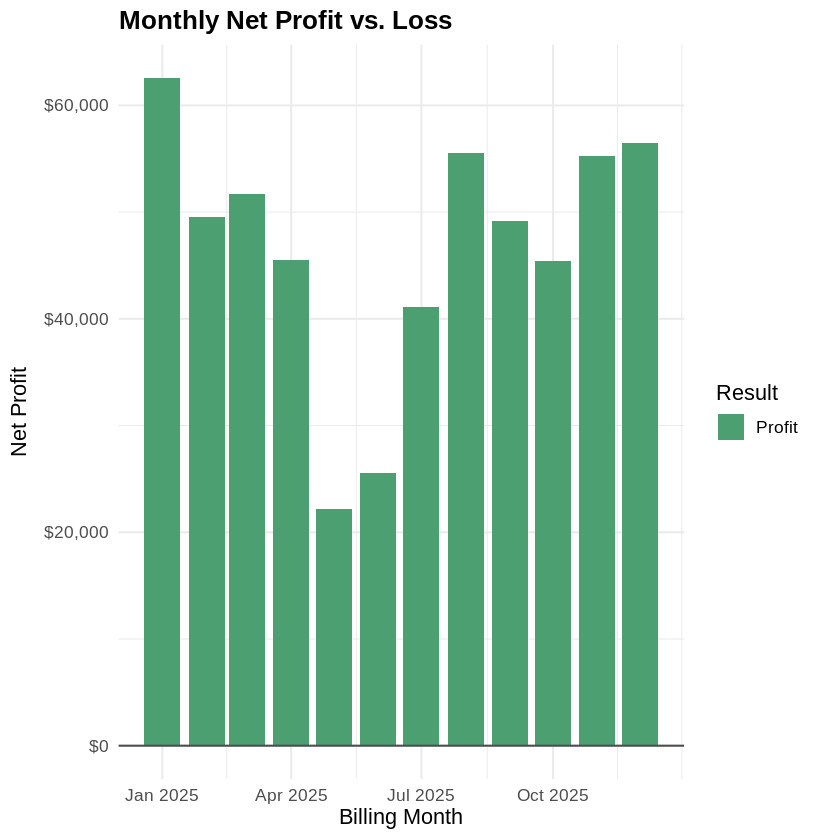

In [83]:
theme_risk <- theme_minimal(base_size = 13) + theme(plot.title = element_text(face = "bold"))

plot_balance_distribution <- ggplot(unified_ledger, aes(x = Remaining_Balance, fill = Critical_Alert)) +
  geom_histogram(bins = 30, alpha = 0.85, position = "identity") +
  scale_fill_manual(values = c("FALSE" = "#4C9F70", "TRUE" = "#D64545"), labels = c("Standard", "Critical Alert")) +
  scale_x_continuous(labels = scales::dollar_format()) +
  labs(title = "Distribution of Remaining Balances", x = "Remaining Balance", y = "Accounts", fill = "Status") +
  theme_risk

plot_risk_matrix <- ggplot(unified_ledger, aes(x = Days_Past_Due, y = Remaining_Balance, color = Risk_Tier)) +
  geom_point(alpha = 0.75, size = 2.4) +
  scale_color_manual(values = c("Clear" = "#4C9F70", "Watch" = "#E8B339", "Critical" = "#E06C3B", "Severe" = "#B5251F")) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(title = "Risk Matrix: Balance vs. Days Past Due", x = "Days Past Due", y = "Remaining Balance", color = "Risk Tier") +
  theme_risk

monthly_pnl <- unified_ledger %>% group_by(Billing_Month) %>%
  summarise(Total_Net_Profit = sum(Net_Profit), .groups = "drop") %>%
  mutate(Result = ifelse(Total_Net_Profit >= 0, "Profit", "Loss"))

plot_monthly_pnl <- ggplot(monthly_pnl, aes(x = Billing_Month, y = Total_Net_Profit, fill = Result)) +
  geom_col() + geom_hline(yintercept = 0, color = "grey30") +
  scale_fill_manual(values = c("Profit" = "#4C9F70", "Loss" = "#B5251F")) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(title = "Monthly Net Profit vs. Loss", x = "Billing Month", y = "Net Profit") +
  theme_risk

print(plot_balance_distribution)
print(plot_risk_matrix)
print(plot_monthly_pnl)

ggsave("outputs/charts/balance_distribution.png", plot_balance_distribution, width = 8, height = 5, dpi = 150)
ggsave("outputs/charts/risk_matrix.png", plot_risk_matrix, width = 8, height = 5, dpi = 150)
ggsave("outputs/charts/monthly_pnl.png", plot_monthly_pnl, width = 8, height = 5, dpi = 150)


## 6. Pursuit Prediction Model — "is this account worth pursuing?"

Uses your 2 real Kaggle datasets:
- `kingabzpro/bank-debt-data` — has a real recovered/not-recovered outcome, the cleanest label source
- `kotich/banking-collections-dataset-synthetic-data` — richer risk features


**Before running this section:** upload the 3 CSVs to `data/raw/`, then run
`inspect_dataset()` on each and confirm the column names in `CONFIG` below
actually match. Kaggle gates full schema previews behind login, so `CONFIG`
below is a best-effort starting mapping, not a confirmed one — this section
is written to fail with a clear message if a column name is wrong rather
than silently guess around it.


In [84]:
inspect_dataset <- function(path, n_max = 5000) {
  df <- readr::read_csv(path, n_max = n_max, show_col_types = FALSE)
  cat("\n=====", path, "=====\n")
  cat("Columns:", paste(names(df), collapse = ", "), "\n")
  cat("Rows sampled:", nrow(df), "\n\n")
  print(dplyr::glimpse(df))
  invisible(df)
}

# Run these once your files are uploaded to data/raw/, then fix CONFIG below:
# inspect_dataset("data/raw/bank_data.csv")
# inspect_dataset("data/raw/banking_collections_dataset.csv")


In [85]:
CONFIG <- list(
  bank_debt = list(
    path = "data/raw/bank_data.csv",
    id_col = "id", expected_recovery_col = "expected_recovery_amount",
    actual_recovery_col = "actual_recovery_amount", strategy_col = "recovery_strategy",
    age_col = "age", has_outcome = TRUE
  ),
  collections = list(
    path = "data/raw/banking_collections_dataset.csv",
    id_col = "Customer_ID", balance_col = "Outstanding_Amount", original_col = "Loan_Amount",
    risk_col = "Risk_Level", days_past_due_col = "Days_Past_Due",
    outcome_col = "Payment_Status", outcome_paid_values = c("Paid"), has_outcome = TRUE
  ),
  invoice_delay = list(
  path = "data/raw/Dataset.csv",
  id_col = "Cust_Num",
  amount_col = "Amount",
  delay_flag_col = "DelayFlag"
)
)


In [86]:
standardize_bank_debt <- function(cfg) {
  df <- readr::read_csv(cfg$path, show_col_types = FALSE)
  tibble(Source = "bank_debt", Record_ID = as.character(df[[cfg$id_col]]),
         Outcome_Repaid = as.integer(df[[cfg$actual_recovery_col]] > 0),
         Balance_Amount = df[[cfg$expected_recovery_col]], Debt_Ratio = 1,
         Days_Past_Due = 0, # Impute NA to 0
         Risk_Flag = 0L)   # Impute NA to 0
}

standardize_collections <- function(cfg) {
  df <- readr::read_csv(cfg$path, show_col_types = FALSE)
  outcome <- if (!is.null(cfg$outcome_col) && cfg$outcome_col %in% names(df)) {
    as.integer(df[[cfg$outcome_col]] %in% cfg$outcome_paid_values)
  } else NA_integer_
  tibble(Source = "collections", Record_ID = as.character(df[[cfg$id_col]]),
         Outcome_Repaid = outcome, Balance_Amount = df[[cfg$balance_col]],
         Debt_Ratio = df[[cfg$balance_col]] / pmax(df[[cfg$original_col]], 1),
         Days_Past_Due = df[[cfg$days_past_due_col]],
         Risk_Flag = as.integer(tolower(df[[cfg$risk_col]]) %in% c("high", "severe", "critical")))
}

standardize_invoice_delay <- function(cfg) {
  df <- readr::read_csv(cfg$path, show_col_types = FALSE)
  tibble(
    Source = "invoice_delay",
    Record_ID = as.character(df[[cfg$id_col]]),
    Outcome_Repaid = as.integer(df[[cfg$delay_flag_col]] == 0),  # 0 = not delayed
    Balance_Amount = df[[cfg$amount_col]],
    Debt_Ratio = 1,  # no credit-limit equivalent in this dataset
    Days_Past_Due = NA_real_,
    Risk_Flag = NA_integer_
  )
}

safe_standardize <- function(fn, cfg, label) {
  tryCatch(fn(cfg), error = function(e) {
    warning(glue("Could not standardize '{label}': {conditionMessage(e)}. Check CONFIG${label} against inspect_dataset() output."))
    NULL
  })
}

modeling_data <- bind_rows(
  safe_standardize(standardize_bank_debt, CONFIG$bank_debt, "bank_debt"),
  safe_standardize(standardize_collections, CONFIG$collections, "collections"),
  safe_standardize(standardize_invoice_delay, CONFIG$invoice_delay, "invoice_delay")
)

message(glue("Combined modeling table: {nrow(modeling_data)} rows from {n_distinct(modeling_data$Source)} source(s)."))

New names:
• `Weekday_due` -> `Weekday_due...25`
• `Weekday_due` -> `Weekday_due...29`
Combined modeling table: 48721 rows from 3 source(s).



In [87]:
table(readr::read_csv(CONFIG$invoice_delay$path, show_col_types = FALSE)$DelayFlag)

New names:
• `Weekday_due` -> `Weekday_due...25`
• `Weekday_due` -> `Weekday_due...29`



    0     1 
15743 30096 

In [88]:
# readr::read_csv(CONFIG$collections$path, show_col_types = FALSE) %>% pull(Days_Past_Due) %>% summary()


### Train / validation / test split

In [89]:
labeled_data <- modeling_data %>% filter(!is.na(Outcome_Repaid), Source %in% c("collections", "invoice_delay"))
message(glue("{nrow(labeled_data)} rows across {n_distinct(labeled_data$Source)} source(s)."))
labeled_data %>% group_by(Source) %>% summarise(n = n(), pct_repaid = mean(Outcome_Repaid))

46839 rows across 2 source(s).



Source,n,pct_repaid
<chr>,<int>,<dbl>
collections,1000,0.3250000
invoice_delay,45839,0.3434412


In [90]:
split_dataset <- function(df, train_frac = 0.70, val_frac = 0.15, seed = 42) {
  set.seed(seed)
  n <- nrow(df); idx <- sample(seq_len(n))
  train_end <- floor(train_frac * n); val_end <- floor((train_frac + val_frac) * n)
  list(train = df[idx[1:train_end], ], val = df[idx[(train_end + 1):val_end], ], test = df[idx[(val_end + 1):n], ])
}

In [91]:
splits <- split_dataset(labeled_data)
message(glue("Train: {nrow(splits$train)} | Validation: {nrow(splits$val)} | Test: {nrow(splits$test)}"))

payment_model <- glm(
  Outcome_Repaid ~ Balance_Amount + Debt_Ratio,
  data = splits$train, family = binomial(link = "logit"), na.action = na.exclude
)
summary(payment_model)

Train: 32787 | Validation: 7026 | Test: 7026




Call:
glm(formula = Outcome_Repaid ~ Balance_Amount + Debt_Ratio, family = binomial(link = "logit"), 
    data = splits$train, na.action = na.exclude)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -8.723e-01  1.406e-01  -6.206 5.43e-10 ***
Balance_Amount  9.530e-08  1.562e-07   0.610    0.542    
Debt_Ratio      2.200e-01  1.412e-01   1.558    0.119    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 42137  on 32786  degrees of freedom
Residual deviance: 42134  on 32784  degrees of freedom
AIC: 42140

Number of Fisher Scoring iterations: 4


In [92]:

sapply(splits$train[, c("Balance_Amount", "Debt_Ratio", "Days_Past_Due", "Risk_Flag")], function(x) sum(is.na(x)))

Balance_Amount     Debt_Ratio  Days_Past_Due      Risk_Flag 
             0              0          32787          32086

In [93]:
readr::read_csv(CONFIG$collections$path, show_col_types = FALSE) %>% count(Risk_Level)

Risk_Level,n
<chr>,<int>
High,354
Low,268
Medium,378


In [94]:
labeled_data %>% group_by(Source) %>% summarise(n = n(), pct_repaid = mean(Outcome_Repaid))


Source,n,pct_repaid
<chr>,<int>,<dbl>
collections,1000,0.3250000
invoice_delay,45839,0.3434412


In [95]:

labeled_data %>%
  group_by(Outcome_Repaid) %>%
  summarise(n = n(), mean_balance = mean(Balance_Amount), pct_high_risk = mean(Risk_Flag))

Outcome_Repaid,n,mean_balance,pct_high_risk
<int>,<int>,<dbl>,<dbl>
0,30771,19696.75,NA
1,16068,20349.10,NA


### Train the model

In [96]:
payment_model <- glm(
  Outcome_Repaid ~ Balance_Amount + Debt_Ratio,
  data = splits$train, family = binomial(link = "logit"), na.action = na.exclude
)

summary(payment_model)


Call:
glm(formula = Outcome_Repaid ~ Balance_Amount + Debt_Ratio, family = binomial(link = "logit"), 
    data = splits$train, na.action = na.exclude)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -8.723e-01  1.406e-01  -6.206 5.43e-10 ***
Balance_Amount  9.530e-08  1.562e-07   0.610    0.542    
Debt_Ratio      2.200e-01  1.412e-01   1.558    0.119    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 42137  on 32786  degrees of freedom
Residual deviance: 42134  on 32784  degrees of freedom
AIC: 42140

Number of Fisher Scoring iterations: 4


### Evaluate — this is where your model stats live

In [97]:
evaluate_model <- function(model, data, threshold = 0.5, label = "set") {
  data <- data %>% filter(!is.na(Balance_Amount))
  pred_prob <- predict(model, newdata = data, type = "response")
  pred_class <- as.integer(pred_prob > threshold)
  actual <- data$Outcome_Repaid
  valid <- !is.na(pred_class) & !is.na(actual)
  pred_class <- pred_class[valid]; actual <- actual[valid]; pred_prob <- pred_prob[valid]

  accuracy <- mean(pred_class == actual)
  pos <- pred_prob[actual == 1]; neg <- pred_prob[actual == 0]
  auc <- if (length(pos) > 0 && length(neg) > 0) {
    mean(outer(pos, neg, ">")) + 0.5 * mean(outer(pos, neg, "=="))
  } else NA_real_

  cat(glue("--- {label} ---\n"))
  cat(glue("Accuracy: {round(accuracy, 3)}   AUC: {round(auc, 3)}\n"))
  cat("Confusion matrix:\n"); print(table(Predicted = pred_class, Actual = actual)); cat("\n")
  invisible(list(accuracy = accuracy, auc = auc))
}

evaluate_model(payment_model, splits$val, label = "Validation")
evaluate_model(payment_model, splits$test, label = "Test")

saveRDS(payment_model, "models/payment_model.rds")
message("Model saved to models/payment_model.rds")


--- Validation ---Accuracy: 0.659   AUC: 0.486Confusion matrix:
         Actual
Predicted    0    1
        0 4632 2394

--- Test ---Accuracy: 0.651   AUC: 0.478Confusion matrix:
         Actual
Predicted    0    1
        0 4577 2449



Model saved to models/payment_model.rds



### Testing against new data later (this is the whole point, right?)

Two things you'll want as the project grows:

1. **Reload the saved model** without retraining:
   `payment_model <- readRDS("models/payment_model.rds")`
2. **Score any new CSV** through the same standardization the model was
   trained on — `predict_new_accounts()` below does this for a file shaped
   like your Master Ledger / unified_ledger. For a genuinely new *source*
   dataset (different columns), write a `standardize_*()` function for it
   the same way the three above were written, then call `predict()` on the
   result.


In [98]:
predict_new_accounts <- function(new_csv_path, model) {
  new_data <- readr::read_csv(new_csv_path, show_col_types = FALSE)
  validate_schema(new_data, MASTER_LEDGER_SCHEMA, "New accounts file")

  scored <- new_data %>%
    mutate(
      Remaining_Balance = Original_Debt - Amount_Paid,
      Balance_Amount = Remaining_Balance,
      Debt_Ratio = Remaining_Balance / pmax(Original_Debt, 1),
      Days_Past_Due = as.integer(Sys.Date() - Billing_Month),
      Risk_Flag = 0L  # unknown for a brand-new file unless it also has blacklist/external-debt columns
    )
  scored$Predicted_Payment_Probability <- predict(model, newdata = scored, type = "response")
  scored %>% arrange(desc(Predicted_Payment_Probability))
}

# Example:
# new_predictions <- predict_new_accounts("data/raw/some_new_batch.csv", payment_model)


### Score current accounts and rank who's worth pursuing

In [99]:
score_unified_ledger <- function(unified_ledger, model) {
  scoring_input <- unified_ledger %>%
    mutate(
      Balance_Amount = Remaining_Balance,
      Debt_Ratio = Remaining_Balance / pmax(Original_Debt, 1),
      Risk_Flag = as.integer(Is_Blacklisted | Has_External_Debts)
    )
  scoring_input$Predicted_Payment_Probability <- predict(model, newdata = scoring_input, type = "response")

  scoring_input %>%
    mutate(
      Expected_Recovery_Value = round(Predicted_Payment_Probability * Remaining_Balance, 2),
      Worth_Pursuing = case_when(
        !Critical_Alert ~ "Not Flagged",
        Predicted_Payment_Probability >= 0.6 ~ "High Priority",
        Predicted_Payment_Probability >= 0.3 ~ "Medium Priority",
        TRUE ~ "Low Priority - consider write-off"
      )
    ) %>%
    select(Debtor_ID, Debtor_Name, Remaining_Balance, Critical_Alert, Risk_Tier,
           Predicted_Payment_Probability, Expected_Recovery_Value, Worth_Pursuing) %>%
    arrange(desc(Expected_Recovery_Value))
}

pursuit_rankings <- score_unified_ledger(unified_ledger, payment_model)
write_csv(pursuit_rankings, "outputs/pursuit_rankings.csv")
head(pursuit_rankings, 15)


Debtor_ID,Debtor_Name,Remaining_Balance,Critical_Alert,Risk_Tier,Predicted_Payment_Probability,Expected_Recovery_Value,Worth_Pursuing
<int>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<chr>
23,Debtor_0023,9819.10,FALSE,Watch,0.3341551,3281.10,Not Flagged
47,Debtor_0047,9501.59,FALSE,Watch,0.3371002,3202.99,Not Flagged
106,Debtor_0106,9335.25,TRUE,Severe,0.3331562,3110.10,Medium Priority
226,Debtor_0226,8729.66,FALSE,Watch,0.3366591,2938.92,Not Flagged
238,Debtor_0238,8724.43,FALSE,Watch,0.3343032,2916.61,Not Flagged
220,Debtor_0220,8498.78,FALSE,Watch,0.3322857,2824.02,Not Flagged
65,Debtor_0065,8318.86,TRUE,Severe,0.3332839,2772.54,Medium Priority
145,Debtor_0145,8163.53,FALSE,Watch,0.3383689,2762.28,Not Flagged
2,Debtor_0002,8369.55,FALSE,Watch,0.3299845,2761.82,Not Flagged


## 7. LLM Chat Layer — ask the data questions in plain English

Calls the Anthropic API directly (`httr` + `jsonlite`, no extra package
needed). You'll need your own API key from
[console.anthropic.com](https://console.anthropic.com) — this is a separate
key from claude.ai, generated under **Settings > API Keys**.

Set it as a Colab secret or environment variable, never hardcode it in the
notebook:

```r
Sys.setenv(ANTHROPIC_API_KEY = "your-key-here")
```

This builds a compact statistical summary of `unified_ledger` (not the raw
rows — keeps it fast and keeps individual debtor data from leaving your
session unnecessarily) and sends that summary plus your question to Claude.


In [100]:
call_llm <- function(prompt, model = "claude-sonnet-5", max_tokens = 1000) {
  api_key <- Sys.getenv("ANTHROPIC_API_KEY")
  if (api_key == "") stop("Set Sys.setenv(ANTHROPIC_API_KEY = ...) first.")

  resp <- httr::POST(
    url = "https://api.anthropic.com/v1/messages",
    httr::add_headers(
      "x-api-key" = api_key,
      "anthropic-version" = "2023-06-01",
      "content-type" = "application/json"
    ),
    body = jsonlite::toJSON(list(
      model = model,
      max_tokens = max_tokens,
      messages = list(list(role = "user", content = prompt))
    ), auto_unbox = TRUE)
  )

  if (httr::status_code(resp) != 200) {
    stop(glue("API error {httr::status_code(resp)}: {httr::content(resp, 'text')}"))
  }

  parsed <- httr::content(resp, "parsed")
  parsed$content[[1]]$text
}

build_data_context <- function(question, data = unified_ledger) {
  # Try to detect a specific debtor mentioned by ID
  id_match <- str_extract(question, "(?i)debtor[_\\s]?0*([0-9]+)")
  target_id <- if (!is.na(id_match)) as.integer(str_extract(id_match, "[0-9]+")) else NA_integer_

  if (!is.na(target_id) && target_id %in% data$Debtor_ID) {
    row <- data %>% filter(Debtor_ID == target_id)
    return(glue(
"Specific account detail:
{paste(capture.output(print(as.data.frame(row))), collapse = '\n')}"
    ))
  }

  # Otherwise, a portfolio-level summary — narrowed to flagged accounts if asked
  if (str_detect(tolower(question), "flagged|critical|worth pursuing")) {
    data <- data %>% filter(Critical_Alert)
  }

  glue(
"Portfolio summary ({nrow(data)} accounts in scope):
- Critical Alert accounts: {sum(data$Critical_Alert)}
- Total outstanding balance: ${format(round(sum(data$Remaining_Balance), 2), big.mark=',')}
- Total net profit: ${format(round(sum(data$Net_Profit), 2), big.mark=',')}
- Risk tier breakdown: {paste(names(table(data$Risk_Tier)), table(data$Risk_Tier), sep=': ', collapse=', ')}
- Blacklisted accounts: {sum(data$Is_Blacklisted)}
- Accounts with external debts: {sum(data$Has_External_Debts)}"
  )
}

ask_data_llm <- function(question, data = unified_ledger) {
  context <- build_data_context(question, data)
  prompt <- glue(
"You are a financial risk analyst assistant. Answer using ONLY the data below.
Be concise and specific with numbers.

{context}

Question: {question}"
  )
  call_llm(prompt)
}

# Example usage once ANTHROPIC_API_KEY is set:
# cat(ask_data_llm("Which risk tier has the most exposure and what should we prioritize?"))


## 8. Wrap-up

Files written by this notebook:
- `data/processed/unified_ledger.csv` — merged, computed dataset
- `outputs/notification_queue.csv` — drafted collection notices
- `outputs/charts/*.png` — the three visualizations
- `models/payment_model.rds` — trained, reloadable model
- `outputs/pursuit_rankings.csv` — ranked "worth pursuing" list

See `README.md` for the full project structure and `PROJECT_PLAN.md` for a
day-by-day breakdown you can turn into hackathon issues/tasks.
